# 5 — L'abstention, ou ce qu'on avait écarté

**Où en est-on.** Chaque notebook de cette suite a mis au jour un choix
invisible : la population de scrutins (`02`), la relation mesurée (`03`), la
méthode (`04`). Celui-ci s'attaque au dernier, et au plus embarrassant — **les
données qu'on a écartées**.

Le notebook `04` exclut les abstentions du modèle de points idéaux, et justifie
ce choix ainsi : « traiter une abstention comme un demi-vote supposerait qu'elle
se situe entre le pour et le contre, ce qui est faux en pratique parlementaire ».

C'était une affirmation, pas un résultat. Ce notebook la teste.

**Ce qu'on établit :**

1. l'abstention est une **décision collective** — 79 % des abstentions
   surviennent quand elle est la ligne du groupe ;
2. elle est **le plus souvent intermédiaire**, contrairement à ce qu'affirmait
   le notebook `04` : les abstentionnistes se situent entre les deux camps dans
   71 % des scrutins, et à mi-chemin en médiane ;
3. elle **décide parfois** : dix votes sur l'ensemble d'un texte se sont joués
   sur un écart inférieur au nombre d'abstentions.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from radar import abstention, analyze, ideal, viz

viz.set_theme("clair")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(75)

polars.config.Config

## 1. Combien, et par qui

Premier point de méthode : le dénominateur. On rapporte les abstentions aux
seuls **suffrages exprimés**, pas à l'effectif de l'Assemblée. Un député absent
n'est pas un abstentionniste : confondre les deux reviendrait à mélanger
l'absentéisme, qui relève de l'agenda, avec l'abstention, qui est un acte
politique.

findfont: Failed to find font weight semibold, now using 700.


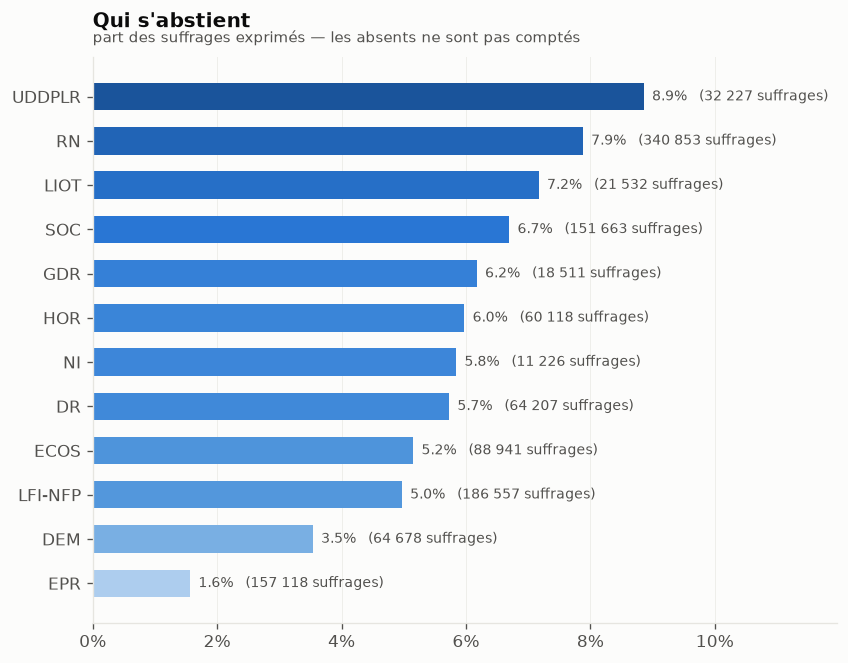

groupe,abstentions,suffrages_exprimes,taux
str,u32,u32,f64
"""UDDPLR""",2855,32227,0.08859
"""RN""",26861,340853,0.078805
"""LIOT""",1544,21532,0.071707
"""SOC""",10156,151663,0.066964
"""GDR""",1143,18511,0.061747
"""HOR""",3592,60118,0.059749
"""NI""",656,11226,0.058436
"""DR""",3679,64207,0.057299
"""ECOS""",4583,88941,0.051529


In [2]:
par_groupe = abstention.taux("groupe")
viz.barres_abstention(par_groupe)
plt.show()
par_groupe

L'écart est considérable : EPR s'abstient six fois moins que le RN. Rien de
mystérieux — le groupe du gouvernement doit soutenir ses textes, il n'a pas le
loisir de ne pas choisir. L'abstention est un luxe d'opposition et de groupe
charnière.

Le taux varie peu selon la portée du scrutin, ce qui est en soi une
information : l'abstention n'est pas réservée aux votes de détail.

In [3]:
abstention.taux("portee")

portee,abstentions,suffrages_exprimes,taux
str,u32,u32,f64
"""texte""",3696,58105,0.063609
"""intermediaire""",8242,132295,0.0623
"""detail""",57155,1007231,0.056745


## 2. Consigne de groupe, ou écart individuel ?

Une abstention peut signifier deux choses opposées. Soit **le groupe s'abstient**
et le député suit : c'est une position collective, le refus assumé de trancher.
Soit **le groupe vote** et le député s'abstient : c'est un écart individuel, une
façon discrète de ne pas suivre.

On tranche en croisant chaque abstention avec la ligne majoritaire de son
groupe — recalculée depuis le dépouillement nominatif, comme partout dans le
radar.

In [4]:
abstention.decomposition()

nature,abstentions,part
str,u32,f64
"""consigne""",51759,0.792137
"""retrait""",13582,0.207863


**Quatre abstentions sur cinq sont des consignes de groupe.** L'abstention n'est
donc pas, à l'Assemblée, l'expression d'une hésitation individuelle : c'est un
instrument collectif.

Ce qui amène une question : une consigne d'abstention est-elle aussi suivie
qu'une consigne de vote ?

In [5]:
abstention.cohesion_par_ligne()

majoritaire,suivi_moyen,occurrences
str,f64,u32
"""pour""",0.968556,17473
"""contre""",0.963991,21134
"""abstention""",0.88432,1770


Non, et l'écart est net : environ 96 % de suivi pour une consigne « pour » ou
« contre », 88 % pour une consigne d'abstention. Une position d'abstention est
un ordre plus mou — souvent le résultat d'un compromis interne, que les membres
les plus tranchés du groupe ne suivent pas.

## 3. Le test : l'abstention est-elle intermédiaire ?

Voici le cœur du notebook, et la vérification de l'affirmation du `04`.

**La méthode.** On estime l'axe des points idéaux sur les seuls « pour » et
« contre ». Les abstentionnistes n'ont donc **pas participé** à la construction
de cet axe. On les y replace ensuite, scrutin par scrutin, et on regarde où
tombe leur position médiane par rapport aux deux camps.

C'est un test hors modèle au sens strict : rien de ce qu'on mesure n'a servi à
fabriquer l'instrument de mesure.

In [6]:
cube = analyze.build_cube(portee="texte")
modele = ideal.estimer(cube, dimensions=1)     # ajusté sans les abstentions

test = abstention.situer_abstentionnistes(cube, modele)
abstention.resume_intermediaire(test)

{'scrutins_testes': 52,
 'part_entre_les_camps': 0.7115384615384616,
 'position_relative_mediane': 0.5172357166425503}

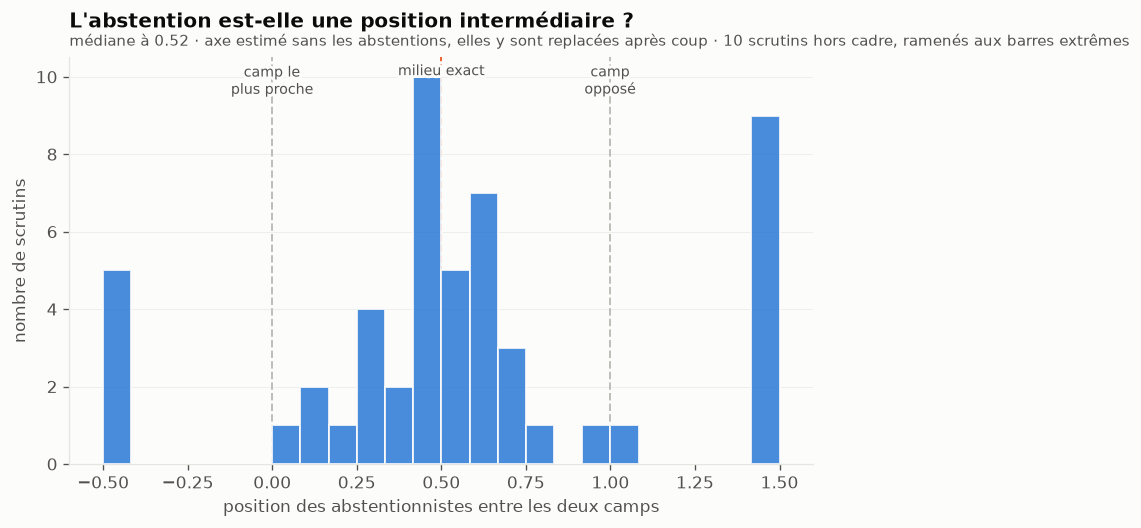

In [7]:
viz.distribution_abstention(test)
plt.show()

**L'affirmation du notebook `04` était trop catégorique.** La distribution est
clairement centrée sur le milieu : médiane à 0,52, et les abstentionnistes
tombent entre les deux camps dans 71 % des scrutins. Dans la majorité des cas,
l'abstention *est* bien une position intermédiaire.

Mais la queue de distribution donne raison à la prudence initiale : dans près
d'un tiers des scrutins, les abstentionnistes se collent à un camp ou le
dépassent. Ce sont les cas où l'abstention n'exprime aucun entre-deux, mais une
opposition qu'on ne veut pas afficher.

Regardons ces deux régimes de plus près.

In [8]:
(test.filter(pl.col("entre_les_camps"))
     .sort("position_relative")
     .with_columns(pl.col("position_relative").round(2))
     .head(5)
     .select("date", "n_abstentions", "position_relative", "titre"))

date,n_abstentions,position_relative,titre
str,i64,f64,str
"""2025-04-01""",16,0.01,"""l'ensemble de la proposition de loi visant à modifier la définition pénale …"
"""2025-12-09""",85,0.12,"""l'ensemble du projet de loi de financement de la sécurité sociale pour 2026…"
"""2025-12-16""",82,0.12,"""l'ensemble du projet de loi de financement de la sécurité sociale pour 2026…"
"""2026-07-15""",28,0.19,"""l'ensemble de la proposition de loi relative au droit à l'aide à mourir (le…"
"""2026-06-23""",64,0.29,"""l'ensemble du projet de loi constitutionnelle pour une Corse autonome au se…"


In [9]:
# Les cas où l'abstention n'a rien d'un compromis.
(test.filter(~pl.col("entre_les_camps"))
     .sort("position_relative", descending=True)
     .with_columns(pl.col("position_relative").round(2))
     .head(5)
     .select("date", "n_abstentions", "position_relative", "titre"))

date,n_abstentions,position_relative,titre
str,i64,f64,str
"""2025-12-11""",20,2.39,"""l'ensemble de la proposition de loi relative à la protection sociale complé…"
"""2026-06-11""",47,1.66,"""l'ensemble de la proposition de loi visant à la nationalisation d'ArcelorMi…"
"""2025-02-20""",30,1.62,"""l'ensemble de la proposition de loi instaurant un impôt plancher de 2 % sur…"
"""2024-11-04""",63,1.58,"""l'ensemble de la deuxième partie du projet de loi de financement de la sécu…"
"""2025-01-28""",60,1.53,"""l'ensemble de la proposition de loi visant à renforcer la lutte contre les …"


**Conséquence pour le modèle.** Faut-il pour autant réintégrer les abstentions
dans `ideal.estimer` ? Non — mais pour une autre raison que celle avancée dans
le `04`. Le modèle logistique à deux paramètres est **binaire par construction**
: il n'a pas de troisième issue à prédire. Les intégrer supposerait un modèle
ordonné, à seuils, qui est un autre travail.

La bonne formulation de la limite est donc : *le modèle ne sait pas représenter
l'abstention, alors qu'elle porte de l'information dans environ sept cas sur
dix.* C'est plus embarrassant que ce que disait le `04`, et plus exact.

## 4. Quand l'abstention décide

Dernier angle, le plus concret. Le critère est arithmétique et vérifiable : si
le nombre d'abstentions dépasse l'écart entre les deux camps, alors les
abstentionnistes avaient les moyens d'inverser le résultat.

On ne prétend rien de leurs intentions — seulement qu'ils tenaient l'issue.

In [10]:
bascule = abstention.scrutins_bascule(portee="texte")
print(f"{bascule.height} votes sur l'ensemble d'un texte où l'abstention tenait l'issue")
bascule.select("date", "n_pour", "n_contre", "n_abstention", "ecart", "sort_code", "titre")

10 votes sur l'ensemble d'un texte où l'abstention tenait l'issue


date,n_pour,n_contre,n_abstention,ecart,sort_code,titre
str,i64,i64,i64,i64,str,str
"""2025-12-02""",217,213,84,4,"""adopté""","""l'ensemble du projet de loi de fin de gestion pour 2025 (texte de la commis…"
"""2025-12-09""",247,234,93,13,"""adopté""","""l'ensemble du projet de loi de financement de la sécurité sociale pour 2026…"
"""2025-12-16""",247,232,90,15,"""adopté""","""l'ensemble du projet de loi de financement de la sécurité sociale pour 2026…"
"""2025-04-02""",63,42,54,21,"""adopté""","""l'ensemble du projet de loi portant diverses dispositions d'adaptation au d…"
"""2025-04-07""",204,180,24,24,"""adopté""","""l'ensemble de la proposition de loi organique visant à harmoniser le mode d…"
"""2025-10-15""",65,41,52,24,"""adopté""","""l'ensemble de la proposition de loi de simplification du droit de l'urbanis…"
"""2025-04-07""",206,181,25,25,"""adopté""","""l'ensemble de la proposition de loi visant à harmoniser le mode de scrutin …"
"""2024-11-04""",126,98,68,28,"""adopté""","""l'ensemble de la deuxième partie du projet de loi de financement de la sécu…"
"""2025-11-18""",107,145,82,38,"""rejeté""","""l'ensemble du projet de loi de finances de fin de gestion pour 2025 (premiè…"


Le plus serré mérite qu'on s'y arrête : un projet de loi de finances adopté par
**217 voix contre 213** — quatre voix d'écart — avec **84 abstentions**.

In [11]:
cas = bascule.row(0, named=True)
print(f"{cas['date']} — {cas['titre'][:110]}")
print(f"{cas['n_pour']} pour / {cas['n_contre']} contre / {cas['n_abstention']} abstentions\n")

abstention.qui_s_abstenait(cas["scrutin_uid"]).head(8)

2025-12-02 — l'ensemble du projet de loi de fin de gestion pour 2025 (texte de la commission mixte paritaire).
217 pour / 213 contre / 84 abstentions



groupe,pour,contre,abstention,total
str,u32,u32,u32,u32
"""SOC""",1,1,59,61
"""ECOS""",0,3,20,23
"""LIOT""",18,0,3,21
"""DR""",43,0,2,45
"""NI""",6,1,0,7
"""DEM""",35,0,0,35
"""GDR""",0,15,0,15
"""EPR""",82,0,0,82


La réponse est sans ambiguïté : le groupe socialiste s'abstient à 59 sur 61, les
écologistes à 20 sur 23. En votant contre, ils faisaient tomber le texte. En
s'abstenant, ils l'ont laissé passer sans avoir à le voter.

Aucune analyse de proximité de vote ne fait apparaître cet épisode : dans les
tables du notebook `01`, ces 59 abstentions comptent comme une position parmi
trois, ni pour ni contre, et se diluent dans une moyenne.

## 5. Ce qu'il faut retenir

| Question | Réponse |
|---|---|
| L'abstention est-elle individuelle ? | Non — 79 % suivent une consigne de groupe. |
| Une consigne d'abstention est-elle suivie ? | Moins bien : 88 % contre 96 % pour un vote. |
| Est-elle une position intermédiaire ? | Oui dans 71 % des scrutins, médiane à 0,52. |
| Faut-il la réintégrer au modèle ? | Pas ainsi : il faudrait un modèle ordonné. |
| Peut-elle décider ? | Oui — 10 votes d'ensemble tenaient sur elle. |

## 6. Limites

- **Le test de position intermédiaire porte sur 52 scrutins**, ceux où chacun
  des trois camps compte au moins dix députés. C'est peu, et la queue de
  distribution repose sur une poignée de cas.
- **Le critère de bascule est arithmétique, pas politique.** Il dit que les
  abstentionnistes tenaient l'issue, pas qu'ils l'ont voulue ni négociée.
- **L'abstention est comparée à un axe estimé sur les votes d'ensemble.** Rien
  ne garantit que la même lecture vaudrait sur les amendements, qui obéissent à
  une autre logique — la leçon du notebook `02` reste valable ici.

En ligne de commande :

```bash
uv run radar abstentions
uv run radar abstentions --bascule
```